# DEWAR General Analysis Notebook

This notebook uses the `dewar_analysis` module to analyze FBG and temperature data from different runs.

**Features:**
- Reusable classes and functions
- Easy to adapt for different dates and time windows
- Comprehensive analysis and plotting tools

## 1. Import Module and Dependencies

In [1]:
# Import the custom analysis module
import sys

# Use the local version (same directory as this notebook)
local_path = '/afs/cern.ch/user/v/vgarciap/rtd-calibration-ana/DEWAR_1M'
if local_path in sys.path:
    sys.path.remove(local_path)
sys.path.insert(0, local_path)

# Force reload if module was already imported
import importlib
if 'dewar_analysis' in sys.modules:
    import dewar_analysis
    importlib.reload(dewar_analysis)

from dewar_analysis import (
    DewarDataLoader, 
    DewarAnalyzer, 
    DewarPlotter,
    SensorConfig,
    quick_analysis
)

import datetime
import matplotlib.pyplot as plt
import numpy as np

print("✓ Modules imported successfully")
print(f"✓ Using dewar_analysis from: {local_path}")

✓ Modules imported successfully
✓ Using dewar_analysis from: /afs/cern.ch/user/v/vgarciap/rtd-calibration-ana/DEWAR_1M


## 2. Quick Analysis - Single Sensor

Use the `quick_analysis` function for a fast overview of a single sensor.

✓ Data loaded from: /eos/user/j/jcapotor/FBGdata/ROOTFiles/Dewar1m/20251119.root
  Peak data range: 2025-11-19 16:09:59.167191982 → 2025-11-20 09:01:53.775902033
  Temp data range: 2025-11-19 16:04:25 → 2025-11-19 23:55:40


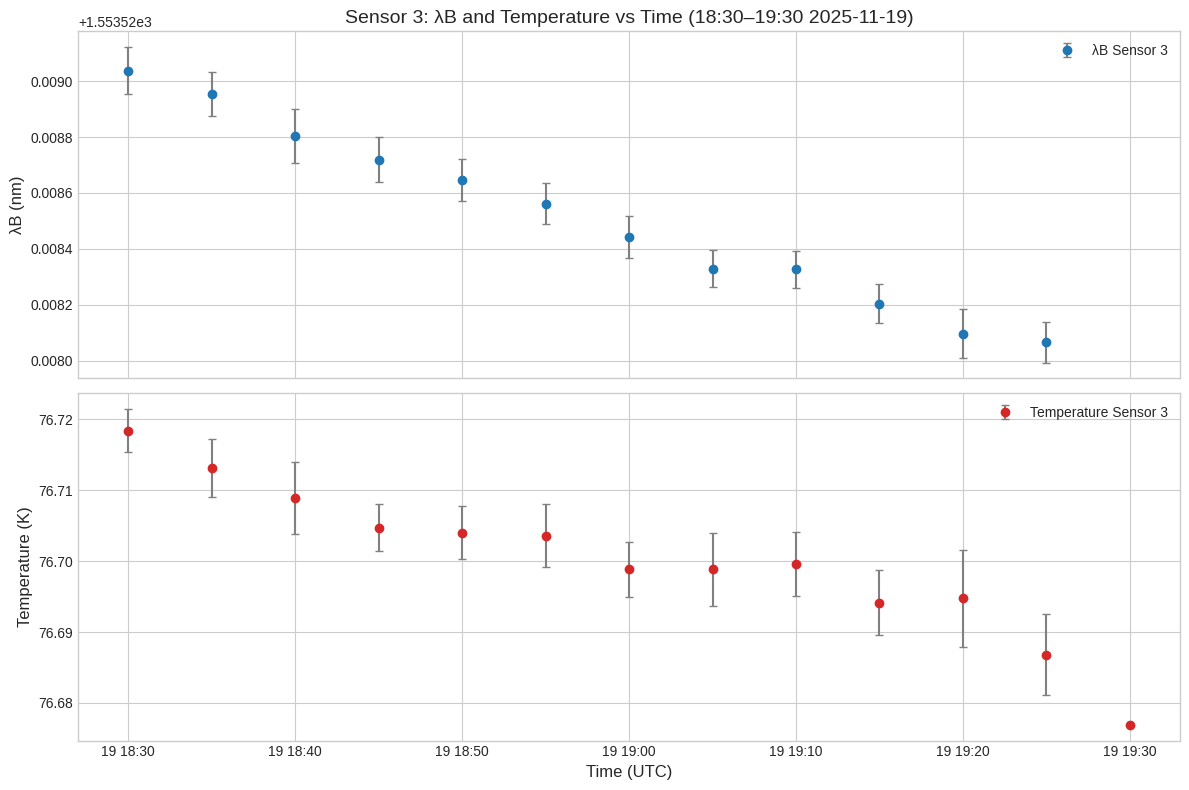

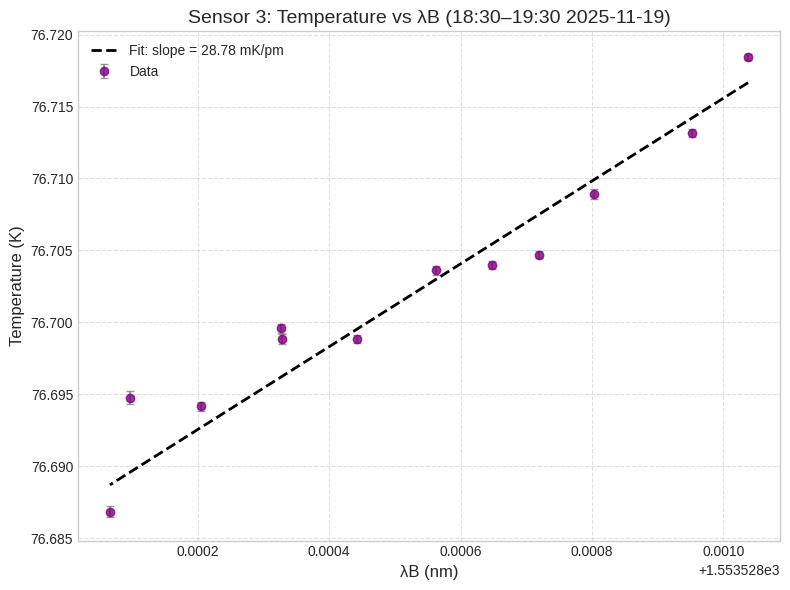


ANALYSIS RESULTS - Sensor 3
Time window: 18:30 - 19:30
Slope: 28.78 mK/pm
Intercept: -44633.72 K
Number of points: 12



In [2]:
# Example: Analyze Sensor 3 from 19 Nov 2025
# Available time range: 16:09 to 23:55 (RTD data limit)

file_path = "/eos/user/j/jcapotor/FBGdata/ROOTFiles/Dewar1m/20251119.root"
date = "2025-11-19"

# Time window configuration - USE DECIMAL HOURS (e.g., 18.5 = 18:30)
start_hour = 18.5  # 18:30
end_hour = 19.5    # 19:30

sensor_idx = 2  # Sensor 3 (0-based index)

loader, analyzer, plotter, fit_results = quick_analysis(
    file_path, date, start_hour, end_hour, sensor_idx
)

## 3. Advanced Analysis - Multiple Sensors

For more control, use the classes directly.

In [22]:
# Configuration
file_path = "/eos/user/j/jcapotor/FBGdata/ROOTFiles/Dewar1m/20251119.root"
start_time = datetime.datetime(2025, 11, 19, 18, 30, 0)
end_time = datetime.datetime(2025, 11, 19, 19, 30, 0)
resample_interval = "5min"

# Load data
loader = DewarDataLoader(file_path, time_correction_hours=2.0)
loader.load_data()

✓ Data loaded from: /eos/user/j/jcapotor/FBGdata/ROOTFiles/Dewar1m/20251119.root
  Peak data range: 2025-11-19 16:09:59.167191982 → 2025-11-20 09:01:53.775902033
  Temp data range: 2025-11-19 16:04:25 → 2025-11-19 23:55:40


In [23]:
# Initialize analyzer and plotter
config = SensorConfig()
analyzer = DewarAnalyzer(loader, config)
plotter = DewarPlotter(config)

print("✓ Analyzer and plotter initialized")

✓ Analyzer and plotter initialized


### 3.1 Plot Multiple Sensors - Temperature vs Wavelength

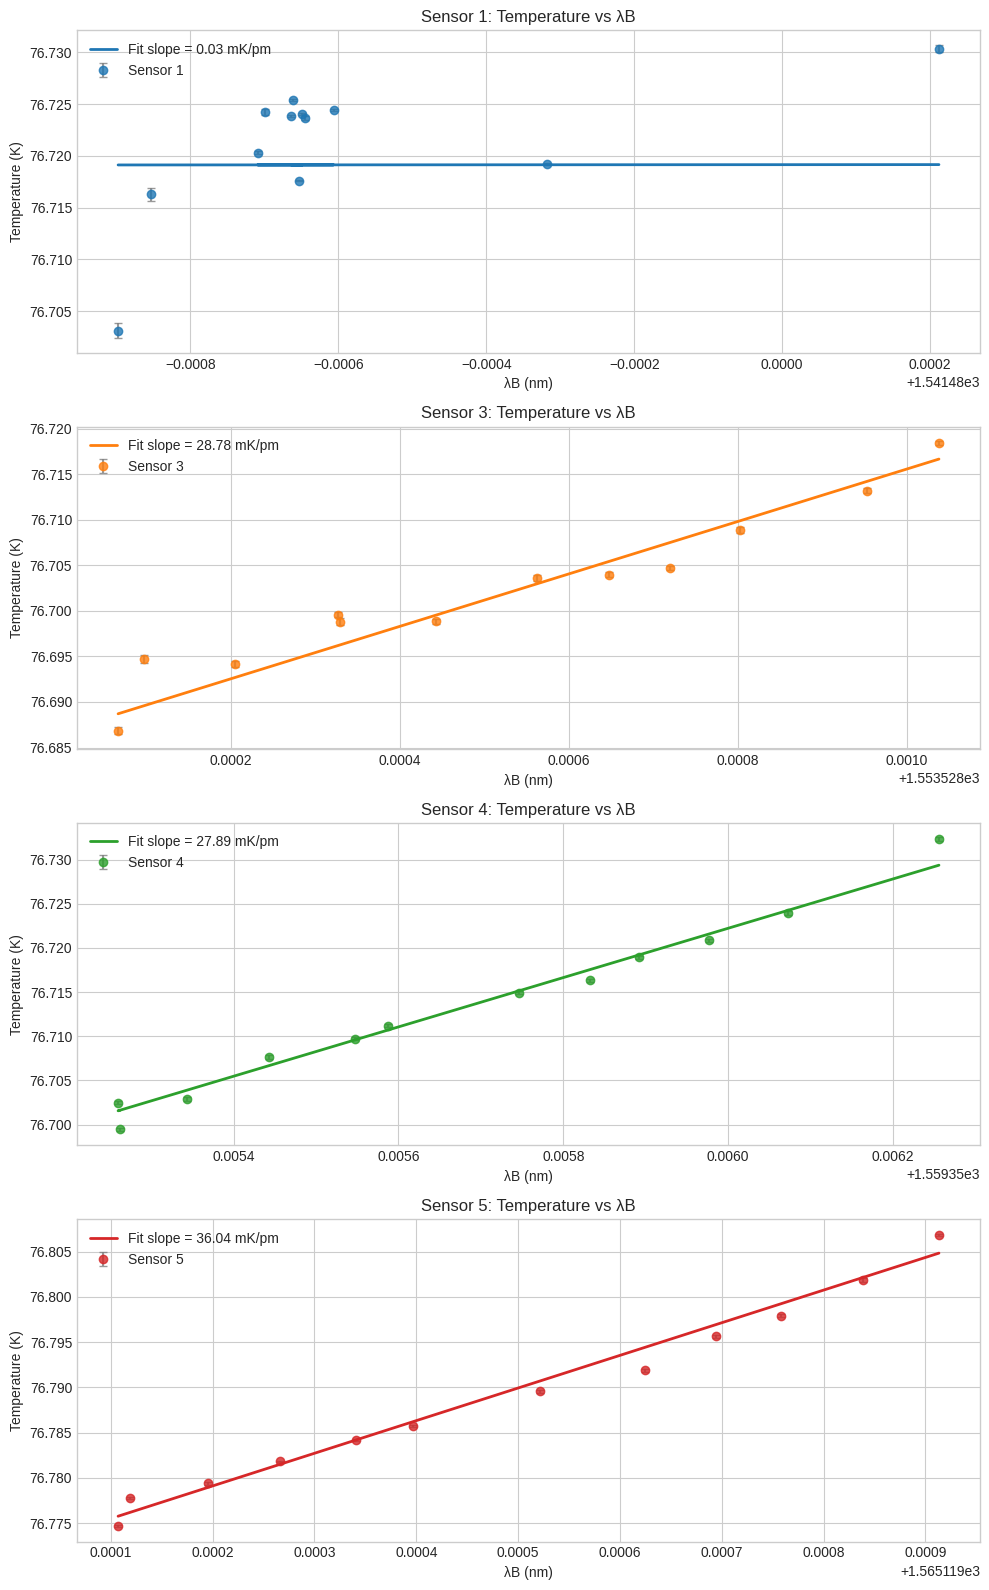

In [24]:
# Sensors to analyze (0-based indices: 0=Sensor1, 2=Sensor3, 3=Sensor4, 4=Sensor5)
sensor_indices = [0, 2, 3, 4]

fig = plotter.plot_multiple_sensors_fit(
    analyzer, sensor_indices, start_time, end_time, resample_interval
)
plt.show()

### 3.2 Individual Sensor Analysis

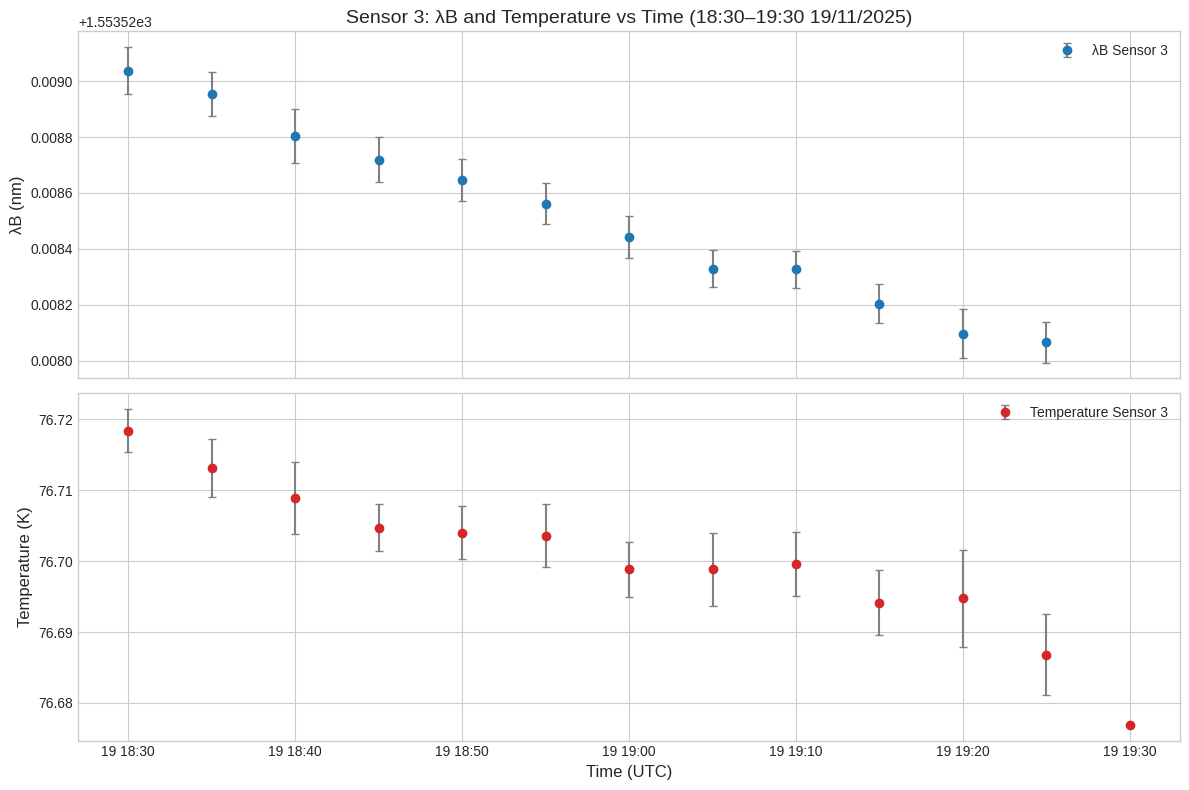

In [16]:
# Analyze a specific sensor
sensor_idx = 2  # Sensor 3

peak_res, temp_res = analyzer.resample_sensor_data(
    sensor_idx, start_time, end_time, resample_interval="5min"
)

# Plot time series
sensor_name = f"Sensor {sensor_idx+1}"
title_suffix = "(18:30–19:30 19/11/2025)"
fig1 = plotter.plot_time_series(peak_res, temp_res, sensor_name, title_suffix)
plt.show()

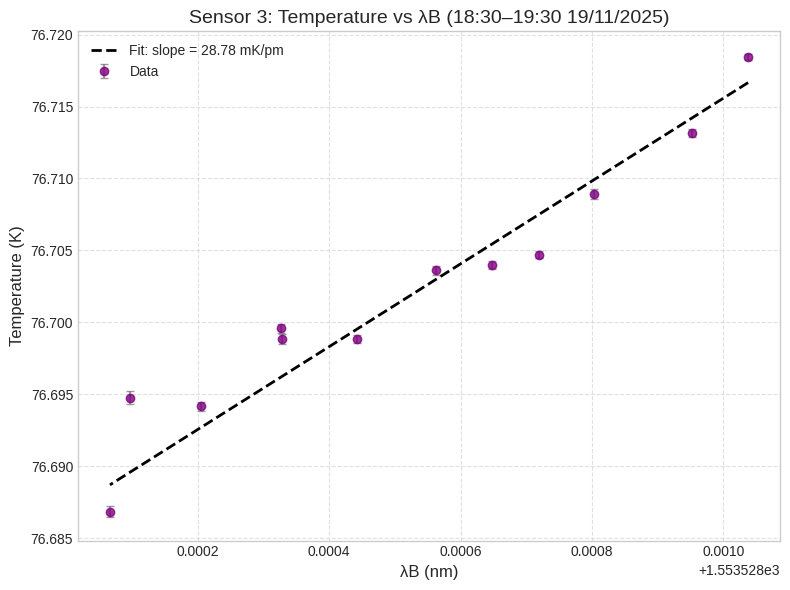


FIT RESULTS - Sensor 3
Slope: 28.7799 mK/pm
Slope: 2.8780e+01 K/nm
Intercept: -44633.72 K
Data points: 12
Residuals std: 2.296e-03 K



In [17]:
# Fit and plot wavelength vs temperature
fit_results = analyzer.fit_temperature_vs_wavelength(peak_res, temp_res)

fig2 = plotter.plot_wavelength_vs_temperature(fit_results, sensor_name, title_suffix)
plt.show()

# Print fit results
print(f"\n{'='*50}")
print(f"FIT RESULTS - {sensor_name}")
print(f"{'='*50}")
print(f"Slope: {fit_results['slope_mK_pm']:.4f} mK/pm")
print(f"Slope: {fit_results['slope_K_nm']:.4e} K/nm")
print(f"Intercept: {fit_results['intercept_K']:.2f} K")
print(f"Data points: {fit_results['n_points']}")
print(f"Residuals std: {np.std(fit_results['residuals']):.3e} K")
print(f"{'='*50}\n")

### 3.3 Sensor Offsets Analysis

Compare all sensors relative to a reference sensor (e.g., Sensor 5).

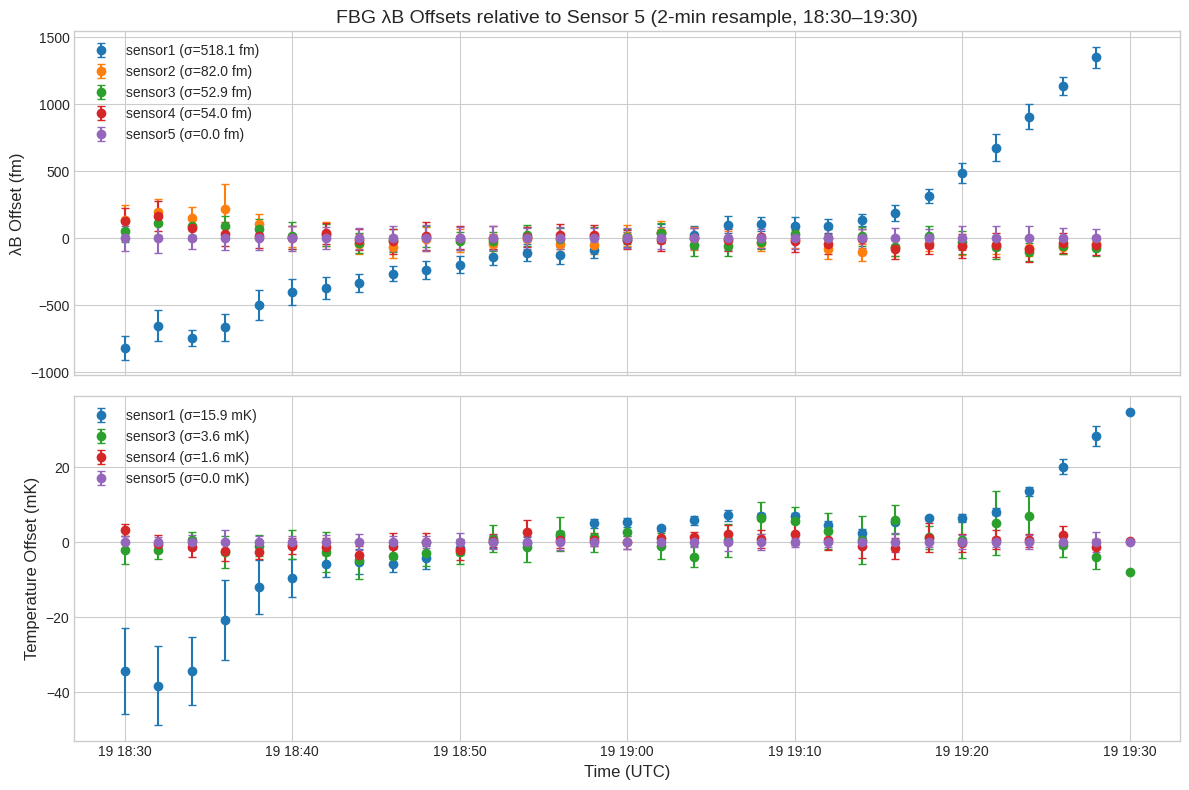

In [19]:
# Compute offsets relative to Sensor 5 (index 4)
lambda_offsets, temp_offsets, peak_res_all, temp_res_all = analyzer.compute_sensor_offsets(
    start_time, end_time, resample_interval="2min", reference_sensor_idx=4
)

# Plot offsets
title_suffix = "relative to Sensor 5 (2-min resample, 18:30–19:30)"
fig = plotter.plot_sensor_offsets(lambda_offsets, temp_offsets, 
                                 peak_res_all, temp_res_all, title_suffix)
plt.show()

### 3.4 Statistics Summary

In [21]:
# Print offset statistics
print("\n" + "="*60)
print("OFFSET STATISTICS (relative to Sensor 5)")
print("="*60)

print("\nWavelength Offsets (fm):")
print("-" * 40)
for col in lambda_offsets.columns:
    mean = lambda_offsets[col].mean()
    std = lambda_offsets[col].std()
    print(f"{col:10s}: mean = {mean:3e} fm,  σ = {std:3e} fm")

print("\nTemperature Offsets (mK):")
print("-" * 40)
for col in temp_offsets.columns:
    mean = temp_offsets[col].mean()
    std = temp_offsets[col].std()
    print(f"{col:10s}: mean = {mean:3e} mK,  σ = {std:3e} mK")

print("="*60 + "\n")


OFFSET STATISTICS (relative to Sensor 5)

Wavelength Offsets (fm):
----------------------------------------
sensor1   : mean = 1.241763e-09 fm,  σ = 5.181055e+02 fm
sensor2   : mean = -1.241763e-09 fm,  σ = 8.203862e+01 fm
sensor3   : mean = -7.450581e-10 fm,  σ = 5.293307e+01 fm
sensor4   : mean = 4.346172e-10 fm,  σ = 5.403299e+01 fm
sensor5   : mean = 0.000000e+00 fm,  σ = 0.000000e+00 fm

Temperature Offsets (mK):
----------------------------------------
sensor1   : mean = -2.750488e-15 mK,  σ = 1.593561e+01 mK
sensor3   : mean = -1.833659e-15 mK,  σ = 3.575721e+00 mK
sensor4   : mean = 4.584147e-16 mK,  σ = 1.587223e+00 mK
sensor5   : mean = 0.000000e+00 mK,  σ = 0.000000e+00 mK



## 4. Batch Analysis - Multiple Runs

Example of analyzing multiple runs with a loop.


Analyzing Run 07/11...
--------------------------------------------------
✓ Data loaded from: /eos/user/j/jcapotor/FBGdata/ROOTFiles/Dewar1m/20251107.root
  Peak data range: 2025-11-07 12:24:03.237097979 → 2025-11-07 17:04:45.582643986
  Temp data range: 2025-11-07 12:22:21 → 2025-11-07 17:03:16
✓ Data loaded from: /eos/user/j/jcapotor/FBGdata/ROOTFiles/Dewar1m/20251107.root
  Peak data range: 2025-11-07 12:24:03.237097979 → 2025-11-07 17:04:45.582643986
  Temp data range: 2025-11-07 12:22:21 → 2025-11-07 17:03:16


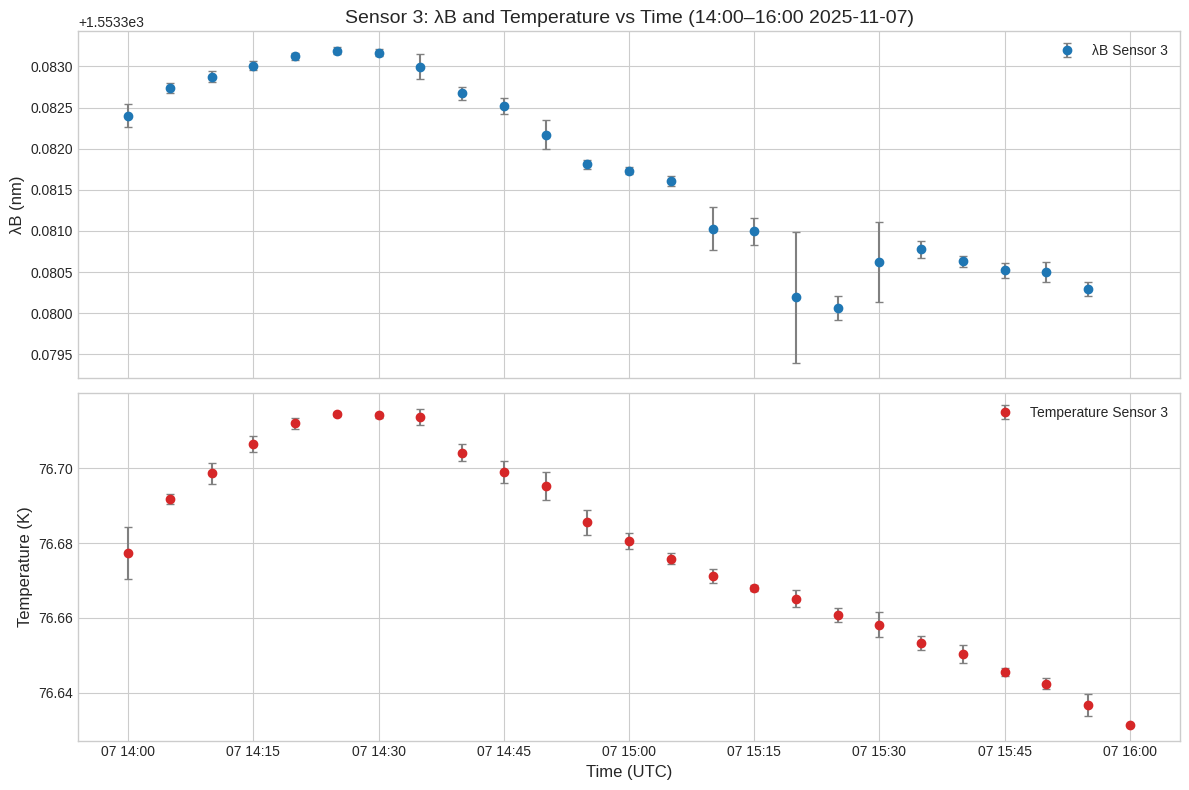

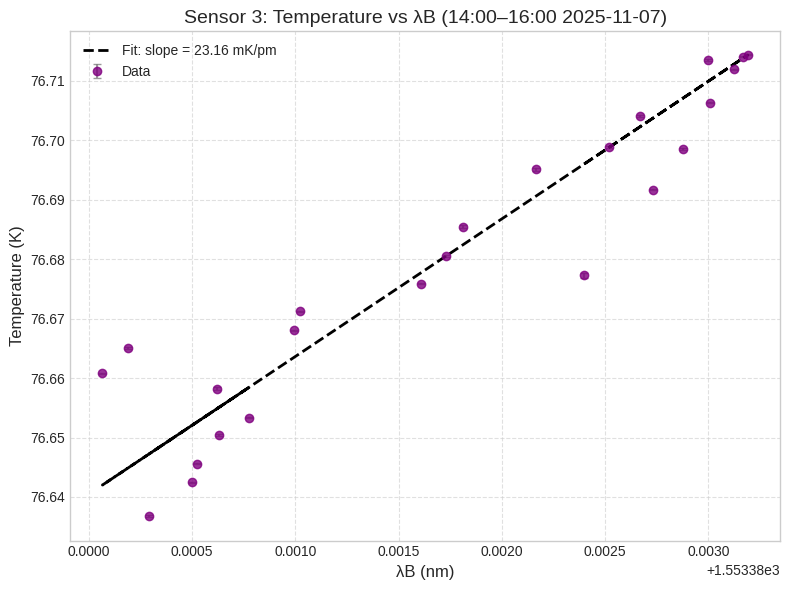


ANALYSIS RESULTS - Sensor 3
Time window: 14:00 - 16:00
Slope: 23.16 mK/pm
Intercept: -35894.10 K
Number of points: 24


Analyzing Run 19/11...
--------------------------------------------------
✓ Data loaded from: /eos/user/j/jcapotor/FBGdata/ROOTFiles/Dewar1m/20251119.root
  Peak data range: 2025-11-19 16:09:59.167191982 → 2025-11-20 09:01:53.775902033
  Temp data range: 2025-11-19 16:04:25 → 2025-11-19 23:55:40
✓ Data loaded from: /eos/user/j/jcapotor/FBGdata/ROOTFiles/Dewar1m/20251119.root
  Peak data range: 2025-11-19 16:09:59.167191982 → 2025-11-20 09:01:53.775902033
  Temp data range: 2025-11-19 16:04:25 → 2025-11-19 23:55:40


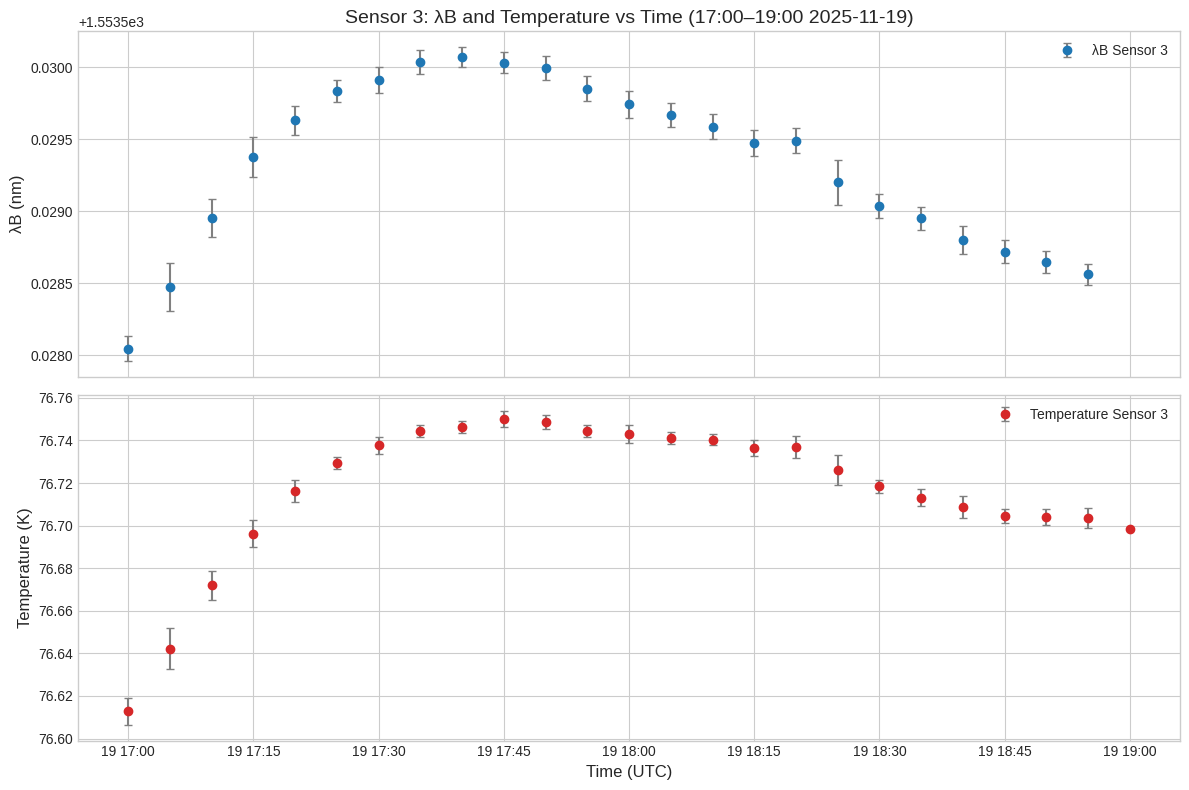

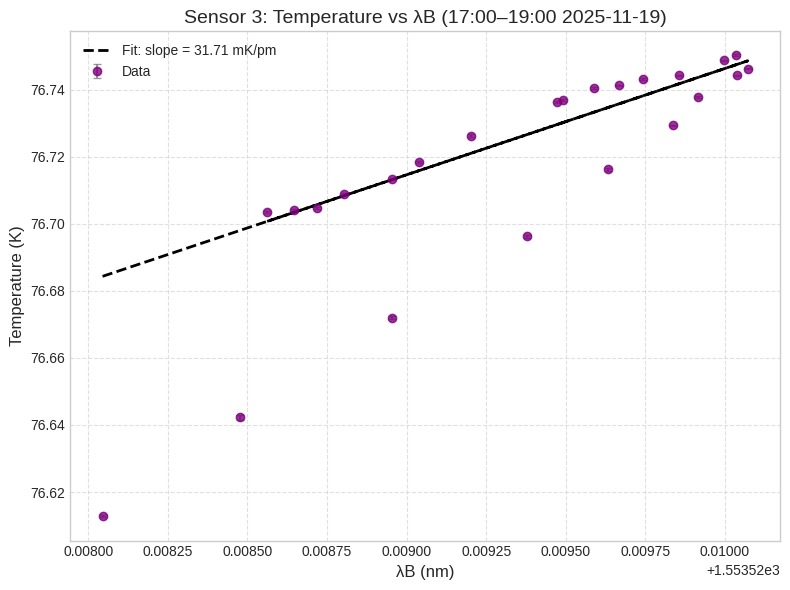


ANALYSIS RESULTS - Sensor 3
Time window: 17:00 - 19:00
Slope: 31.71 mK/pm
Intercept: -49187.38 K
Number of points: 24


BATCH ANALYSIS COMPLETE


In [10]:
# Define multiple runs to analyze
runs = [
    {
        'file': "/eos/user/j/jcapotor/FBGdata/ROOTFiles/Dewar1m/20251107.root",
        'date': "2025-11-07",
        'start': 14,
        'end': 16,
        'label': "Run 07/11"
    },
    {
        'file': "/eos/user/j/jcapotor/FBGdata/ROOTFiles/Dewar1m/20251119.root",
        'date': "2025-11-19",
        'start': 17,
        'end': 19,
        'label': "Run 19/11"
    }
]

# Store results
results = {}

for run in runs:
    print(f"\nAnalyzing {run['label']}...")
    print("-" * 50)
    
    try:
        loader, analyzer, plotter, fit_res = quick_analysis(
            run['file'], run['date'], run['start'], run['end'], 
            sensor_idx=2, resample_interval="5min"
        )
        results[run['label']] = fit_res
    except Exception as e:
        print(f"Error analyzing {run['label']}: {e}")

print("\n" + "="*50)
print("BATCH ANALYSIS COMPLETE")
print("="*50)

### Compare Results Across Runs

In [11]:
# Compare slopes from different runs
print("\nSlope Comparison (Sensor 3):")
print("-" * 50)
for label, fit_res in results.items():
    print(f"{label:15s}: {fit_res['slope_mK_pm']:8.2f} mK/pm")
print("-" * 50)


Slope Comparison (Sensor 3):
--------------------------------------------------
Run 07/11      :    23.16 mK/pm
Run 19/11      :    31.71 mK/pm
--------------------------------------------------


## 5. Export Data

Save processed data for further analysis.

In [12]:
# Example: Save resampled data to CSV
output_dir = "/eos/user/v/vgarciap/SWAN_projects/DUNEHD/CALIB/DEWAR_1M/processed_data"

# Uncomment to save
# import os
# os.makedirs(output_dir, exist_ok=True)
# peak_res.to_csv(f"{output_dir}/peak_resampled_sensor3_20251119.csv")
# temp_res.to_csv(f"{output_dir}/temp_resampled_sensor3_20251119.csv")
# print(f"✓ Data saved to {output_dir}")